In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("/kaggle/input/datasets/agneaybnair/fruits-for-random-forests/data.csv")

print(df.head())
print(df.info())

   Color  Weight(g)  Sweetness  Shape Texture  Fruit
0    Red        180          8  Round  Smooth  Apple
1    Red        170          7  Round  Smooth  Apple
2  Green        175          6  Round  Smooth  Apple
3    Red        190          9  Round  Smooth  Apple
4  Green        185          7  Round  Smooth  Apple
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Color      12 non-null     object
 1   Weight(g)  12 non-null     int64 
 2   Sweetness  12 non-null     int64 
 3   Shape      12 non-null     object
 4   Texture    12 non-null     object
 5   Fruit      12 non-null     object
dtypes: int64(2), object(4)
memory usage: 708.0+ bytes
None


In [3]:
df.describe()
df.isnull().sum()

Color        0
Weight(g)    0
Sweetness    0
Shape        0
Texture      0
Fruit        0
dtype: int64

In [4]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for column in df.columns:
    if df[column].dtype == "object":
        df[column] = encoder.fit_transform(df[column])

df.head()

,Color,Weight(g),Sweetness,Shape,Texture,Fruit
0,1,180,8,1,0,0
1,1,170,7,1,0,0
2,0,175,6,1,0,0
3,1,190,9,1,0,0
4,0,185,7,1,0,0


In [5]:
X = df.drop("Fruit", axis=1)
y = df["Fruit"]

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [8]:
results = X_test.copy()
results["Actual"] = y_test.values
results["Predicted"] = y_pred

print(results)

    Color  Weight(g)  Sweetness  Shape  Texture  Actual  Predicted
10      2        135          9      0        0       1          1
9       2        118          8      0        0       1          1
0       1        180          8      1        0       0          0


In [9]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [10]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1 0]
 [0 2]]


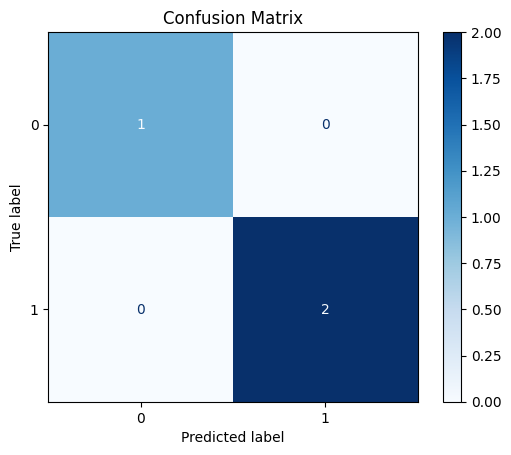

In [11]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap="Blues")

plt.title("Confusion Matrix")
plt.show()